In [300]:
import pandas as pd
from thefuzz import fuzz, process
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# For imputation
# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer

In [396]:
df_train = pd.read_csv("train.csv")

In [397]:
df_test = pd.read_csv("test.csv")

# Data Cleaning function

In [403]:
import pandas as pd
from thefuzz import fuzz, process
import numpy as np

# For imputation
# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer


def clean_car_data(df_train, df_test, fast=True):
    """
    Clean and impute car data for both training and test sets.
    
    IMPORTANT: All imputers and encoders are fit ONLY on training data to prevent data leakage.
    
    Parameters:
    -----------
    df_train : pd.DataFrame
        Training dataset
    df_test : pd.DataFrame
        Test dataset
    fast : bool, default=True
        If True, uses BayesianRidge for imputation (fast).
        If False, uses RandomForestRegressor (slower but potentially better accuracy)
        
    Returns:
    --------
    df_train_cleaned : pd.DataFrame
        Cleaned and imputed training data
    df_test_cleaned : pd.DataFrame
        Cleaned and imputed test data
    """
    
    # ============================================================================
    # SECTION 1: REFERENCE DATA SETUP
    # ============================================================================
    
    # Reference list of correct model names
    models = ["golf", "veloste", "caddy", "yaris", "q2", "fiesta", "2 series", "3 series", "a3", "octavia", 
              "passat", "focus", "insignia", "a class", "q3", "fabia", "ka+", "glc class", "i30", "c class", 
              "polo", "e class", "q5", "up", "c-hr", "mokka x", "corsa", "astra", "tt", "5 series", "aygo", 
              "4 series", "slk", "viva", "t-roc", "ecosport", "tucson", "x-class", "cl class", "ix20", "i20", 
              "rapid", "a1", "auris", "sharan", "adam", "x3", "a8", "gls class", "b-max", "a4", "kona", "i10", 
              "mokka", "s-max", "x2", "crossland x", "tiguan", "a5", "gle class", "zafira", "ioniq", "a6", 
              "mondeo", "yeti outdoor", "x1", "scala", "s class", "1 series", "kamiq", "kuga", "tourneo connect", 
              "q7", "gla class", "arteon", "sl class", "santa fe", "grandland x", "i800", "rav4", "touran", 
              "citigo", "roomster", "prius", "corolla", "b class", "kodiaq", "v class", "caddy maxi life", 
              "superb", "getz", "combo life", "beetle", "galaxy", "m3", "gtc", "x4", "ka", "ix35", 
              "grand tourneo connect", "m4", "tourneo custom", "z4", "x5", "meriva", "rs6", "verso", "touareg", 
              "shuttle", "cls class", "c-max", "puma", "cla class", "i40", "tiguan allspace", "6 series", 
              "caravelle", "karoq", "i3", "grand c-max", "t-cross", "a7", "golf sv", "agila", "gt86", "yeti", 
              "california", "land cruiser", "edge", "x6", "caddy life", "8 series", "fusion", "gl class", 
              "scirocco", "z3", "proace verso", "hilux", "amarok", "cc", "7 series", "avensis", "eos", "m class", 
              "grandland", "zafira tourer", "rs5", "r8", "mustang", "antara", "q8", "camry", "clk", "rs3", 
              "jetta", "kadjar", "sq5", "rs4", "supra", "i8", "x7", "sq7", "g class", "s3", "crossland", 
              "tigra", "escort", "glb class", "vivaro", "verso-s", "m5", "s4", "iq", "a2", "caddy maxi", 
              "streetka", "cascada", "accent", "s8", "rs", "golf s", "ranger", "vectra", "ampera", "fox", 
              "urban cruiser", "m2", "clc class", "m6", "s5", "terracan", "200", "220", "230", "NaN"]
    
    # Get unique short model names (2 characters) for separate handling
    short_models = [models[i] for i in range(len(models)) if len(models[i]) == 2]
    short_models = list(set(short_models))
    
    transmission_types = ["semi-auto", "manual", "automatic", "unkown", "NaN", "other"]
    fuel_types = ["petrol", "diesel", "hybrid", "electric", "other", "NaN"]
    
    # Brand name corrections mapping
    brand_mapping = {
        "vw": "vw",
        "v": "vw",
        "w": "vw",
        
        "toyota": "toyota",
        "toyot": "toyota",
        "oyota": "toyota",
        
        "audi": "audi",
        "aud": "audi",
        "udi": "audi",
        "ud": "audi",
        
        "ford": "ford",
        "for": "ford",
        "ord": "ford",
        "or": "ford",
        
        "bmw": "bmw",
        "bm": "bmw",
        "mw": "bmw",
        
        "skoda": "skoda",
        "skod": "skoda",
        "koda": "skoda",
        "kod": "skoda",
        
        "opel": "opel",
        "ope": "opel",
        "pel": "opel",
        "pe": "opel",
        
        "mercedes": "mercedes",
        "mercede": "mercedes",
        "ercedes": "mercedes",
        "ercede": "mercedes",
        
        "hyundai": "hyundai",
        "hyunda": "hyundai",
        "yundai": "hyundai",
        "yunda": "hyundai"
    }
    
    # ============================================================================
    # SECTION 2: INITIAL CLEANING (NO FITTING REQUIRED) -> no risk of data leakage
    # ============================================================================
    
    def process_dataframe(df):
        """
        Apply string cleaning, brand/model corrections, and fuzzy matching.
        These operations don't require fitting on training data.
        """
        df = df.copy()
        
        # Convert brand names to lowercase and removes all beginning and trailing whitespace (e.g. space) from the column
        df["Brand"] = df["Brand"].str.lower().str.strip()
        df["model"] = df["model"].str.lower().str.strip()
        df["transmission"] = df["transmission"].str.lower().str.strip()
        df["fuelType"] = df["fuelType"].str.lower().str.strip()
        
        # Replace NaN with string NaN to avoid errors in the fuzzy algorithm (cant match NaNs)
        df[["model", "transmission", "fuelType"]] = df[["model", "transmission", "fuelType"]].fillna("NaN")
        
        # 1.1 Fixing brands
        df["Brand"] = df["Brand"].map(brand_mapping)
        
        # 1.2 Fixing models
        # Similarity matching for Models, Transmission and fuel columns (Fuzzy Match)
        # Source for process.extractOne (fuzzy): https://github.com/seatgeek/thefuzz
        
        # VECTORIZED APPROACH: Only perform fuzzy matching once per unique value instead of per row
        
        # Models - handle different lengths separately
        unique_models = df["model"].unique()
        model_lookup = {}
        for val in unique_models:
            if pd.isna(val) or val == "NaN":
                model_lookup[val] = "NaN"
            elif len(val) > 2:  # Only perform fuzzy matching for models that have a name longer than 2 letters -> fuzzy will become fuzzy (unreliable) if names are to short
                model_lookup[val] = process.extractOne(val, models)[0]  # [0] because we get the name and score as a return -> score used for debugging
            elif len(val) == 2:  # Use the short names list for comparisons if the model names are 2 letters
                model_lookup[val] = process.extractOne(val, short_models)[0]
            else:  # We can define models with only one letter
                model_lookup[val] = "NaN"
        df["model"] = df["model"].map(model_lookup)
        
        # Transmission
        unique_trans = df["transmission"].unique()
        trans_lookup = {val: process.extractOne(val, transmission_types)[0] for val in unique_trans}
        df["transmission"] = df["transmission"].map(trans_lookup)
        
        # FuelType
        unique_fuel = df["fuelType"].unique()
        fuel_lookup = {val: process.extractOne(val, fuel_types)[0] for val in unique_fuel}
        df["fuelType"] = df["fuelType"].map(fuel_lookup)
        
        # Convert the str NaN values back to pd.NA for easier further processing and readability
        df["model"] = df["model"].replace("NaN", pd.NA)
        df["transmission"] = df["transmission"].replace(["unkown", "NaN", "other"], pd.NA)
        df["fuelType"] = df["fuelType"].replace(["other", "NaN"], pd.NA)
        
        # Get the most frequent brand for each model -> returns df with model and brand
        brand_models = df.groupby("model")["Brand"].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else pd.NA)
        df = pd.merge(df, brand_models, on="model", how="left", suffixes=('', '_mode'))  # add the model and brand df to our main df (onyl add the brand columns, join on model)
        
        df["Brand"] = df["Brand"].fillna(df['Brand_mode'])  # rename new column
        df.drop('Brand_mode', axis=1, inplace=True)  # remove the old brand column
        
        # Cleaning numeric columns
        df['year'] = df['year'].round(0)
        
        # Create the new column
        df["stated_no_damage"] = ~df["hasDamage"].astype(bool)
        df = df.drop(["hasDamage"], axis=1)
        
        return df
    
    # Apply preprocessing to both datasets
    df_train = process_dataframe(df_train)
    df_test = process_dataframe(df_test)
    
    # ============================================================================
    # SECTION 3: ENCODING (FIT ON TRAIN, TRANSFORM BOTH) -> Risk of data leakage
    # ============================================================================
    
    def encode_dataframe(df, encoders=None, fit=False):
        """
        Encode categorical columns using LabelEncoder.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Dataframe to encode
        encoders : dict or None
            Dictionary of fitted encoders. If None and fit=True, new encoders are created
        fit : bool
            If True, fit encoders on this data. If False, use provided encoders
            
        Returns:
        --------
        df_encoded : pd.DataFrame
            Encoded dataframe
        encoders : dict (only if fit=True)
            Dictionary of fitted encoders
        """
        df = df.copy()
        
        # Fill the missing values with String value -> this is important for the encoding as it only works with one datatype per column
        df["Brand"] = df["Brand"].fillna("MISSING_VALUE")
        df["model"] = df["model"].fillna("MISSING_VALUE")
        df["transmission"] = df["transmission"].fillna("MISSING_VALUE")
        df["fuelType"] = df["fuelType"].fillna("MISSING_VALUE")
        
        if fit:
            # Train and apply the encoder (ONLY ON TRAINING DATA)
            brand_labels = LabelEncoder()
            model_labels = LabelEncoder()
            transmission_labels = LabelEncoder()
            fuelType_labels = LabelEncoder()
            
            df['brand_encoded'] = brand_labels.fit_transform(df['Brand'])
            df['model_encoded'] = model_labels.fit_transform(df['model'])
            df['transmission_encoded'] = transmission_labels.fit_transform(df['transmission'])
            df['fuelType_encoded'] = fuelType_labels.fit_transform(df['fuelType'])
            
            encoders = {
                'brand': brand_labels,
                'model': model_labels,
                'transmission': transmission_labels,
                'fuelType': fuelType_labels
            }
        else:
            # Use pre-fitted encoders (FOR TEST DATA)
            df['brand_encoded'] = encoders['brand'].transform(df['Brand'])
            df['model_encoded'] = encoders['model'].transform(df['model'])
            df['transmission_encoded'] = encoders['transmission'].transform(df['transmission'])
            df['fuelType_encoded'] = encoders['fuelType'].transform(df['fuelType'])
        
        # Get the encoding for "MISSING_VALUE"
        # And replace the encoding for missing values with NaN
        
        # Brand column
        missing_code = encoders['brand'].transform(["MISSING_VALUE"])[0]
        df['brand_encoded'] = df['brand_encoded'].replace(missing_code, np.nan)
        
        # model column
        missing_code = encoders['model'].transform(["MISSING_VALUE"])[0]
        df['model_encoded'] = df['model_encoded'].replace(missing_code, np.nan)
        
        # transmission column
        missing_code = encoders['transmission'].transform(["MISSING_VALUE"])[0]
        df['transmission_encoded'] = df['transmission_encoded'].replace(missing_code, np.nan)
        
        # fuelType column
        missing_code = encoders['fuelType'].transform(["MISSING_VALUE"])[0]
        df["fuelType_encoded"] = df["fuelType_encoded"].replace(missing_code, np.nan)
        
        if fit:
            return df, encoders
        else:
            return df
    
    # Fit encoders on training data, then apply to both datasets
    df_train_encoded, encoders = encode_dataframe(df_train, fit=True)
    df_test_encoded = encode_dataframe(df_test, encoders=encoders, fit=False)
    
    # ============================================================================
    # SECTION 4: IMPUTATION (FIT ON TRAIN, TRANSFORM BOTH) -> Risk of data leakage
    # ============================================================================
    
    # Feature definitions
    numerical_features = ["year", "mileage", "tax", "mpg", "engineSize", "paintQuality%", "previousOwners"]
    categorical_features = ["brand_encoded", "transmission_encoded", "fuelType_encoded", "model_encoded"]
    all_features = categorical_features + numerical_features
    features_without_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"] + numerical_features
    categorical_features_no_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"]
    
    def impute_dataframe(df, encoders, imputers=None, fit=False):
        """
        Impute missing values using IterativeImputer for numerical and KNNImputer for categorical.
        Also handles brand-specific model imputation.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Encoded dataframe to impute
        encoders : dict
            Dictionary of label encoders for decoding
        imputers : dict or None
            Dictionary of fitted imputers. If None and fit=True, new imputers are created
        fit : bool
            If True, fit imputers on this data. If False, use provided imputers
            
        Returns:
        --------
        df_imputed : pd.DataFrame
            Imputed and decoded dataframe
        imputers : dict (only if fit=True)
            Dictionary of fitted imputers
        """
        df = df.copy()
        
        if fit:
            # Give option to perform imputation with basic estimator (BaysianRidge) or Random Forest Regressor
            # If we use the Random Forest Regressor compuationtime will increase to up to 2 min compared to 0.8s without it
            if fast:
                estimator_selection = None
            else:
                # Could use a random forrest to better deal with complex connection of the columns
                estimator_selection = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=12)
            
            # Step 3: Apply IterativeImputer
            numerical_imputer = IterativeImputer(
                estimator=estimator_selection,
                max_iter=10,  # Number of imputation rounds
                random_state=12,  # For reproducibility
                initial_strategy="mean"  # Initial fill strategy
            )
            
            categorical_imputer = KNNImputer(
                n_neighbors=10,  # Consider 10 most similar cars
                weights='distance',  # Closer neighbors have more influence
                metric='nan_euclidean'  # Handles missing values properly
            )
            
            # FIT imputers on training data
            numerical_imputer.fit(df[all_features])
            categorical_imputer.fit(df[features_without_model])
            
            imputers = {
                'numerical': numerical_imputer,
                'categorical': categorical_imputer,
                'brand_imputers': {}  # Will be populated below
            }
        
        # Use all dataframe features so relationships are captured for numerical imputation
        temp_imputed = imputers['numerical'].transform(df[all_features])
        df[numerical_features] = temp_imputed[:, len(categorical_features):]
        
        # Impute categorical columns using most_freqent
        temp_cat = imputers['categorical'].transform(df[features_without_model])
        df[categorical_features_no_model] = temp_cat[:, :3].round()
        
        # Brand
        n_brand_classes = len(encoders['brand'].classes_)
        brand_clipped = np.clip(df['brand_encoded'].round(), 0, n_brand_classes - 1).astype(int)
        df['Brand'] = encoders['brand'].inverse_transform(brand_clipped)
        
        # Transmission
        n_transmission_classes = len(encoders['transmission'].classes_)
        transmission_clipped = np.clip(df['transmission_encoded'].round(), 0, n_transmission_classes - 1).astype(int)
        df['transmission'] = encoders['transmission'].inverse_transform(transmission_clipped)
        
        # FuelType
        n_fuelType_classes = len(encoders['fuelType'].classes_)
        fuelType_clipped = np.clip(df['fuelType_encoded'].round(), 0, n_fuelType_classes - 1).astype(int)
        df['fuelType'] = encoders['fuelType'].inverse_transform(fuelType_clipped)
        
        # STEP 2: Impute missing models, split by BRAND
        brands = df['Brand'].unique()
        
        for brand in brands:
            # Skip if brand is NaN
            if pd.isna(brand):
                continue
            
            # Create a sub dataframe with only one brand
            brand_mask = df['Brand'] == brand
            brand_subset = df[brand_mask].copy()
            
            # Check if this brand has any missing models
            if not brand_subset['model_encoded'].isna().any():
                continue
            
            # Find all the valid model codes for this brand
            valid_model_codes = brand_subset.loc[
                brand_subset['model_encoded'].notna(),
                'model_encoded'
            ].unique()
            
            # Impute model within this brand
            model_features = ["model_encoded"] + numerical_features + ["transmission_encoded", "fuelType_encoded", "brand_encoded"]
            
            if fit:
                # FIT a new imputer for this specific brand (ONLY ON TRAINING DATA)
                knn_model_imputer = KNNImputer(n_neighbors=10, weights='distance')
                knn_model_imputer.fit(brand_subset[model_features])
                imputers['brand_imputers'][brand] = knn_model_imputer
            else:
                # USE pre-fitted imputer for this brand (FOR TEST DATA)
                # If this brand wasn't in training data, skip imputation for this brand
                if brand not in imputers['brand_imputers']:
                    continue
                knn_model_imputer = imputers['brand_imputers'][brand]
            
            imputed = knn_model_imputer.transform(brand_subset[model_features])
            imputed_models = imputed[:, 0].round()
            
            # Validate imputed values
            for i, original_val in enumerate(brand_subset['model_encoded'].values):
                if pd.isna(original_val):
                    predicted_code = imputed_models[i]
                    
                    if predicted_code not in valid_model_codes:
                        # Use most common model for this brand
                        most_common = brand_subset['model_encoded'].mode()[0]
                        imputed_models[i] = most_common
            
            df.loc[brand_mask, "model_encoded"] = imputed_models
        
        # Decode models
        n_model_classes = len(encoders['model'].classes_)
        model_clipped = np.clip(df['model_encoded'].round(), 0, n_model_classes - 1).astype(int)
        df['model'] = encoders['model'].inverse_transform(model_clipped)
        
        # Removing encoded columns
        df.drop(["brand_encoded", "model_encoded", "transmission_encoded", "fuelType_encoded"], axis=1, inplace=True)
        
        # Final numeric cleanup and rounding
        df.year = df.year.round()
        df.mileage = abs(df.mileage.round())
        df.tax = abs(df.tax.round())
        df.mpg = df.mpg.round(1)
        df.engineSize = df.engineSize.round(1)
        
        # Assumption:
        # values <4 where entered with a wrong comma
        # values >100 are have a unnecessary leading 1
        def fix_paint_quality(x):
            if x < 4:
                return x * 10
            elif x > 100:
                return x - 100
            else:
                return x
        
        df["paintQuality%"] = df["paintQuality%"].apply(fix_paint_quality).round()
        
        df.previousOwners = abs(df.previousOwners.round())
        
        if fit:
            return df, imputers
        else:
            return df
    
    # Fit imputers on training data, then apply to both datasets
    df_train_final, imputers = impute_dataframe(df_train_encoded, encoders, fit=True)
    df_test_final = impute_dataframe(df_test_encoded, encoders, imputers=imputers, fit=False)
    
    return df_train_final, df_test_final

In [394]:
df["Brand"] = df["Brand"].str.lower().str.strip() # Convert brand names to lowercase and removes all beginning and trailing whitespace (e.g. space) from the column
df["model"] = df["model"].str.lower().str.strip()
df["transmission"] = df["transmission"].str.lower().str.strip()
df["fuelType"] = df["fuelType"].str.lower().str.strip()
df[["model", "transmission", "fuelType"]] = df[["model", "transmission", "fuelType"]].fillna("NaN") # Replace NaN with string NaN to avoid errors in the fuzzy algorithm (cant match NaNs)


# 1.1 Fixing brands 
brand_mapping = {
"vw": "vw",
"v": "vw",
"w": "vw",

"toyota": "toyota",
"toyot": "toyota",
"oyota": "toyota",

"audi": "audi",
"aud": "audi",
"udi": "audi",
"ud": "audi",

"ford": "ford",
"for": "ford",
"ord": "ford",
"or": "ford",

"bmw": "bmw",
"bm": "bmw",
"mw": "bmw",

"skoda": "skoda",
"skod": "skoda",
"koda": "skoda",
"kod": "skoda",

"opel": "opel",
"ope": "opel",
"pel": "opel",
"pe": "opel",

"mercedes": "mercedes",
"mercede": "mercedes",
"ercedes": "mercedes",
"ercede": "mercedes",

"hyundai": "hyundai",
"hyunda": "hyundai",
"yundai": "hyundai",
"yunda": "hyundai"
}

df["Brand"] = df["Brand"].map(brand_mapping)

# 1.2 Fixing models
# Similarity matching for Models, Transmission and fuel columns (Fuzzy Match)
models = ["golf", "veloste", "caddy", "yaris", "q2", "fiesta", "2 series", "3 series", "a3", "octavia", "passat", "focus", "insignia", "a class", "q3", "fabia", "ka+", "glc class", "i30", "c class", "polo", "e class", "q5", "up", "c-hr", "mokka x", "corsa", "astra", "tt", "5 series", "aygo", "4 series", "slk", "viva", "t-roc", "ecosport", "tucson", "x-class", "cl class", "ix20", "i20", "rapid", "a1", "auris", "sharan", "adam", "x3", "a8", "gls class", "b-max", "a4", "kona", "i10", "mokka", "s-max", "x2", "crossland x", "tiguan", "a5", "gle class", "zafira", "ioniq", "a6", "mondeo", "yeti outdoor", "x1", "scala", "s class", "1 series", "kamiq", "kuga", "tourneo connect", "q7", "gla class", "arteon", "sl class", "santa fe", "grandland x", "i800", "rav4", "touran", "citigo", "roomster", "prius", "corolla", "b class", "kodiaq", "v class", "caddy maxi life", "superb", "getz", "combo life", "beetle", "galaxy", "m3", "gtc", "x4", "ka", "ix35", "grand tourneo connect", "m4", "tourneo custom", "z4", "x5", "meriva", "rs6", "verso", "touareg", "shuttle", "cls class", "c-max", "puma", "cla class", "i40", "tiguan allspace", "6 series", "caravelle", "karoq", "i3", "grand c-max", "t-cross", "a7", "golf sv", "agila", "gt86", "yeti", "california", "land cruiser", "edge", "x6", "caddy life", "8 series", "fusion", "gl class", "scirocco", "z3", "proace verso", "hilux", "amarok", "cc", "7 series", "avensis", "eos", "m class", "grandland", "zafira tourer", "rs5", "r8", "mustang", "antara", "q8", "camry", "clk", "rs3", "jetta", "kadjar", "sq5", "rs4", "supra", "i8", "x7", "sq7", "g class", "s3", "crossland", "tigra", "escort", "glb class", "vivaro", "verso-s", "m5", "s4", "iq", "a2", "caddy maxi", "streetka", "cascada", "accent", "s8", "rs", "golf s", "ranger", "vectra", "ampera", "fox", "urban cruiser", "m2", "clc class", "m6", "s5", "terracan", "200", "220", "230", "NaN"]

short_models = [models[i] for i in range(len(models)) if len(models[i]) == 2]
short_models = list(set(short_models)) # get unique short model names as a list

transmission_types = ["semi-auto", "manual", "automatic", "unkown", "NaN", "other"]
fuel_types = ["petrol", "diesel", "hybrid", "electric", "other", "NaN"]

# Source for process.extractOne (fuzzy): https://github.com/seatgeek/thefuzz

# Use fuzzy matching to create a look-up dictonary for the wrongly speld column values
# In the dict the key is the wrongly spelled name and the value the correct one identified by fuzzy match
# We do this for all the unique values we have in the column and map the dictionary to the column
# This is a lot faster than ittering through the column and checking each value seperatly

# For models
unique_models = df["model"].unique()
model_lookup = {}
for val in unique_models:
    if pd.isna(val) or val == "NaN":
        model_lookup[val] = "NaN"  # Keep NaN as NaN
    elif len(val) > 2: # Mapping for model names longer than 2 characters
        model_lookup[val] = process.extractOne(val, models)[0] 
    elif len(val) == 2: # Mapping for models with lenght 2
        model_lookup[val] = process.extractOne(val, short_models)[0]
    else: # for models with length of 1 we assign nan because we cant accuratly map them
        model_lookup[val] = "NaN"

# Map to the column
df["model"] = df["model"].map(model_lookup)

# For transmission 
unique_trans = df["transmission"].unique()
trans_lookup = {val: process.extractOne(val, transmission_types)[0] for val in unique_trans}
df["transmission"] = df["transmission"].map(trans_lookup)

# For fuelType
unique_fuel = df["fuelType"].unique()
fuel_lookup = {val: process.extractOne(val, fuel_types)[0] for val in unique_fuel}
df["fuelType"] = df["fuelType"].map(fuel_lookup)



# Convert the str NaN values back to pd.NA for easier further processing and readability
df["model"] = df["model"].replace("NaN", pd.NA)
df["transmission"] = df["transmission"].replace(["unkown", "NaN", "other"], pd.NA)
df["fuelType"] = df["fuelType"].replace(["other", "NaN"], pd.NA)

brand_models = df.groupby("model")["Brand"].agg(lambda x: x.mode()) # Get the most frequent brand for each model -> returns df with model and brand
df = pd.merge(df, brand_models, on="model", how="left") # add the model and brand df to our main df (onyl add the brand columns, join on model)


df = df.rename(columns={"Brand_x": "Brand"}) # rename new column
df["Brand"] = df["Brand"].fillna(df['Brand_y'])
df.drop('Brand_y', axis=1, inplace=True) # remove the old brand column
#
#cols = ["carID", "Brand", "model", "year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage'] # rearange column order
#df = df[cols]

# Cleaning numeric columns
df['year'] = df['year'].round(0)

# Create the new column
df["stated_no_damage"] = ~df["hasDamage"].astype(bool)
df = df.drop(["hasDamage"], axis=1)

In [ ]:
"""# Copy for plotting
df2 = df.copy()
df2 = df2.drop(["model","carID"], axis=1)"""

# End of cleaning without data leakage risk

In [371]:
"""df.shape"""

(32567, 13)

In [372]:
"""df.isna().sum()"""

carID                  0
Brand                 16
model                727
year                 653
transmission         971
mileage              689
fuelType             738
tax                 3308
mpg                 3288
engineSize           628
paintQuality%        625
previousOwners       597
stated_no_damage       0
dtype: int64

# Beginning of Cleaning with risk of data leakage

# Imputation

In [373]:
df_encoded = df.copy()

# Use LabelEncoder for categorical columns
brand_labels = LabelEncoder()
model_labels = LabelEncoder()
transmission_labels = LabelEncoder()
fuelType_labels = LabelEncoder()

# Fill the missing values with String value -> this is important for the encoding as it only works with one datatype per column
df_encoded["Brand"] = df_encoded["Brand"].fillna("MISSING_VALUE") 
df_encoded["model"] = df_encoded["model"].fillna("MISSING_VALUE")
df_encoded["transmission"] = df_encoded["transmission"].fillna("MISSING_VALUE")
df_encoded["fuelType"] = df_encoded["fuelType"].fillna("MISSING_VALUE")

# Train and apply the encoder
df_encoded['brand_encoded'] = brand_labels.fit_transform(df_encoded['Brand']) 
df_encoded['model_encoded'] = model_labels.fit_transform(df_encoded['model']) 
df_encoded['transmission_encoded'] = transmission_labels.fit_transform(df_encoded['transmission']) 
df_encoded['fuelType_encoded'] = fuelType_labels.fit_transform(df_encoded['fuelType']) 

# Get the encoding for "MISSING_VALUE"
# And replace the encoding for missing values with NaN
# Brand column
missing_code = brand_labels.transform(["MISSING_VALUE"])[0] 
df_encoded['brand_encoded'] = df_encoded['brand_encoded'].replace(missing_code, np.nan) 
# model column
missing_code = model_labels.transform(["MISSING_VALUE"])[0] 
df_encoded['model_encoded'] = df_encoded['model_encoded'].replace(missing_code, np.nan) 
# transmission column 
missing_code = transmission_labels.transform(["MISSING_VALUE"])[0] 
df_encoded['transmission_encoded'] = df_encoded['transmission_encoded'].replace(missing_code, np.nan) 
# fuelType column
missing_code = fuelType_labels.transform(["MISSING_VALUE"])[0] 
df_encoded["fuelType_encoded"] = df_encoded["fuelType_encoded"].replace(missing_code, np.nan) 


numerical_features = ["year", "mileage", "tax", "mpg", "engineSize", "paintQuality%", "previousOwners"]
categorical_features = ["brand_encoded", "transmission_encoded", "fuelType_encoded", "model_encoded"]

all_features = categorical_features + numerical_features

features_without_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"] + numerical_features


fast = True
# Give option to perform imputation with basic estimator (BaysianRidge) or Random Forest Regressor
# If we use the Random Forest Regressor compuationtime will increase to up to 2 min compared to 0.8s without it
if fast: 
    estimator_selection = None
else: 
    #Could use a random forrest to better deal with complex connection of the columns
    estimator_selection = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=12)

# Step 3: Apply IterativeImputer
numerical_imputer = IterativeImputer(
    estimator= estimator_selection, 
    max_iter=10,           # Number of imputation rounds
    random_state=12,       # For reproducibility
    initial_strategy="mean"  # Initial fill strategy
)

categorical_imputer = KNNImputer(
    n_neighbors=10,        # Consider 10 most similar cars
    weights='distance',    # Closer neighbors have more influence
    metric='nan_euclidean' # Handles missing values properly
)

# Use all dataframe features so relationships are captured for numerical imputation
temp_imputed = numerical_imputer.fit_transform(df_encoded[all_features])
df_encoded[numerical_features] = temp_imputed[:, len(categorical_features):]


# Impute categorical columns using most_freqent 
categorical_features_no_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"]
temp_cat = categorical_imputer.fit_transform(df_encoded[features_without_model])
df_encoded[categorical_features_no_model] = temp_cat[:, :3].round()

# Brand
n_brand_classes = len(brand_labels.classes_)
brand_clipped = np.clip(df_encoded['brand_encoded'].round(), 0, n_brand_classes - 1).astype(int)
df_encoded['Brand'] = brand_labels.inverse_transform(brand_clipped)

# Transmission
n_transmission_classes = len(transmission_labels.classes_)
transmission_clipped = np.clip(df_encoded['transmission_encoded'].round(), 0, n_transmission_classes - 1).astype(int)
df_encoded['transmission'] = transmission_labels.inverse_transform(transmission_clipped)

# FuelType
n_fuelType_classes = len(fuelType_labels.classes_)
fuelType_clipped = np.clip(df_encoded['fuelType_encoded'].round(), 0, n_fuelType_classes - 1).astype(int)
df_encoded['fuelType'] = fuelType_labels.inverse_transform(fuelType_clipped)

In [374]:
# STEP 2: Impute missing models, split by BRAND
brands = df_encoded['Brand'].unique()

for brand in brands:
    # Skip if brand is NaN
    if pd.isna(brand):
        continue
    
    # Create a sub dataframe with only one brand 
    brand_mask = df_encoded['Brand'] == brand
    brand_subset = df_encoded[brand_mask].copy()
    
    # Check if this brand has any missing models
    if not brand_subset['model_encoded'].isna().any():
        continue
    
    # Find all the valid model codes for this brand
    valid_model_codes = brand_subset.loc[
        brand_subset['model_encoded'].notna(), 
        'model_encoded'
    ].unique()
    
    # Impute model within this brand
    model_features = ["model_encoded"] + numerical_features + ["transmission_encoded", "fuelType_encoded", "brand_encoded"]
    
    knn_model_imputer = KNNImputer(n_neighbors=10, weights='distance')
    imputed = knn_model_imputer.fit_transform(brand_subset[model_features])
    imputed_models = imputed[:, 0].round()
    
    # Validate imputed values
    for i, original_val in enumerate(brand_subset['model_encoded'].values):
        if pd.isna(original_val):
            predicted_code = imputed_models[i]
            
            if predicted_code not in valid_model_codes:
                # Use most common model for this brand
                most_common = brand_subset['model_encoded'].mode()[0]
                imputed_models[i] = most_common
    
    df_encoded.loc[brand_mask, "model_encoded"] = imputed_models


n_model_classes = len(model_labels.classes_)
model_clipped = np.clip(df_encoded['model_encoded'].round(), 0, n_model_classes - 1).astype(int)
#model_clipped = df_encoded['model_encoded'].round().astype(int)
df_encoded['model'] = model_labels.inverse_transform(model_clipped)

In [375]:
# Removing encoded columns
df_encoded.drop(["brand_encoded", "model_encoded", "transmission_encoded", "fuelType_encoded"], axis=1, inplace=True)

# Finish cleaning with data leakage risk

In [376]:
"""# Imput shape: 75973, 14)
df_encoded.shape"""

(32567, 13)

In [377]:
"""df_encoded.isna().sum()"""

carID               0
Brand               0
model               0
year                0
transmission        0
mileage             0
fuelType            0
tax                 0
mpg                 0
engineSize          0
paintQuality%       0
previousOwners      0
stated_no_damage    0
dtype: int64

In [378]:
"""for column in df_encoded.columns: 
    print(f"{column}: ")
    print(df_encoded[column].unique())
    print("###########################")"""

carID: 
[ 89856 106581  80886 ...  76833  91768  99627]
###########################
Brand: 
['hyundai' 'vw' 'bmw' 'opel' 'ford' 'mercedes' 'skoda' 'toyota' 'audi']
###########################
model: 
['i30' 'tiguan' '2 series' 'grandland x' '1 series' 'fiesta' 'x1'
 'b class' 'focus' 'superb' '5 series' 'c class' 'up' 'aygo' 'golf'
 'm class' 'land cruiser' 'tt' 'adam' 'zafira' 'e class' '3 series' 'ix20'
 'a4' 'yaris' 'passat' 'i10' 'mokka x' 'ecosport' '4 series' 'a7' 'corsa'
 'kuga' 'grand c-max' 'q2' 'm4' 'a class' 'rav4' 'fabia' 'insignia' 'a1'
 'x6' 'meriva' 'caravelle' 'octavia' 'auris' 'x-class' 'astra' 'v class'
 'polo' 'karoq' 'shuttle' 'mokka' 'q5' 'tucson' 'a3' 'sl class' 'corolla'
 'ka+' 'x3' 'i40' 'i20' 'kamiq' 'ix35' 'crossland x' 'q3' 'viva'
 'gla class' 'cls class' 'ka' 'galaxy' 'x2' 'kodiaq' 'glc class' 'vivaro'
 'mondeo' 'touran' 'cl class' 'x5' 'verso' 'touareg' 't-roc' 'a5'
 's class' 'scirocco' 'x7' 'b-max' '8 series' 'a6' 'santa fe' 'gl class'
 'gle class' 'beetl

In [381]:
df_encoded.year = df_encoded.year.round()
#df_encoded.price = df_encoded.price.round()
df_encoded.mileage = df_encoded.mileage.round()
df_encoded.tax = df_encoded.tax.round()
df_encoded.mpg = df_encoded.mpg.round(1)
df_encoded.engineSize = df_encoded.engineSize.round(1)

# Assumption: 
# values <4 where entered with a wrong comma 
# values >100 are have a unnecessary leading 1
def fix_paint_quality(x):
    if x < 4:
        return x * 10
    elif x > 100:
        return x - 100
    else:
        return x
    
df_encoded["paintQuality%"] = df_encoded["paintQuality%"].apply(fix_paint_quality).round()

df_encoded.previousOwners = abs(df_encoded.previousOwners.round())

In [382]:
df_encoded

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,stated_no_damage
0,89856,hyundai,i30,2023.0,automatic,30700.0,petrol,205.0,41.5,1.6,61.0,3.0,True
1,106581,vw,tiguan,2017.0,semi-auto,-48191.0,petrol,150.0,38.2,2.0,60.0,2.0,True
2,80886,bmw,2 series,2016.0,automatic,36792.0,petrol,125.0,51.4,1.5,94.0,2.0,True
3,100174,opel,grandland x,2019.0,manual,5533.0,petrol,145.0,44.1,1.2,77.0,1.0,True
4,81376,bmw,1 series,2019.0,semi-auto,9058.0,diesel,150.0,51.4,2.0,45.0,4.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32562,105775,vw,tiguan,2017.0,manual,27575.0,petrol,145.0,46.3,1.4,94.0,1.0,True
32563,81363,bmw,x2,2020.0,automatic,1980.0,petrol,145.0,34.0,2.0,39.0,3.0,True
32564,76833,audi,q5,2019.0,semi-auto,8297.0,diesel,145.0,38.2,2.0,88.0,4.0,True
32565,91768,mercedes,a class,2019.0,manual,-50755.0,petrol,145.0,28.5,1.3,81.0,1.0,True


# Correlation Matrix

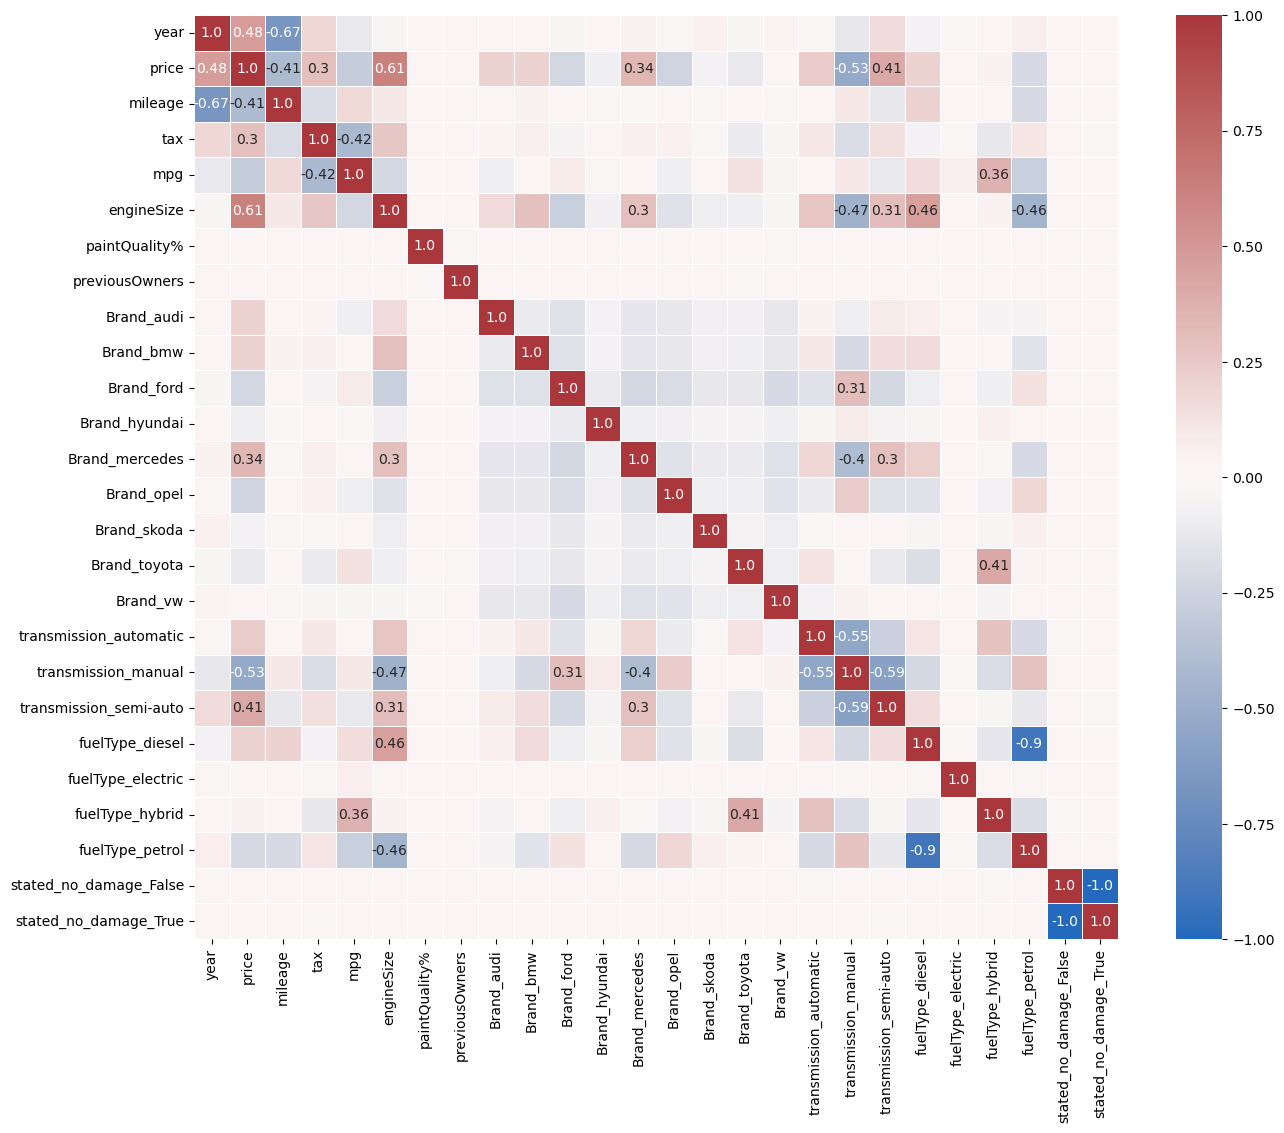

In [ ]:
df_encoded = pd.get_dummies(df2, columns=['Brand', "transmission",  "fuelType", "stated_no_damage"])  # Avoid multicollinearity
correlation_matrix = df_encoded.corr().round(2)

fig = plt.figure(figsize=(15, 12))


sns.heatmap(data=correlation_matrix,
            center = 0,
            cmap="vlag",
            annot=np.where(np.absolute(correlation_matrix) >= 0.3, correlation_matrix.values, np.full(correlation_matrix.values.shape, "")), 
            fmt='s',
            square=True,
            linewidths=.5)

plt.show()

In [ ]:
df_models = df.copy()
df_models = df_models[df.Brand == "vw"]
df_models = df_models.drop(["Brand","carID"], axis=1)

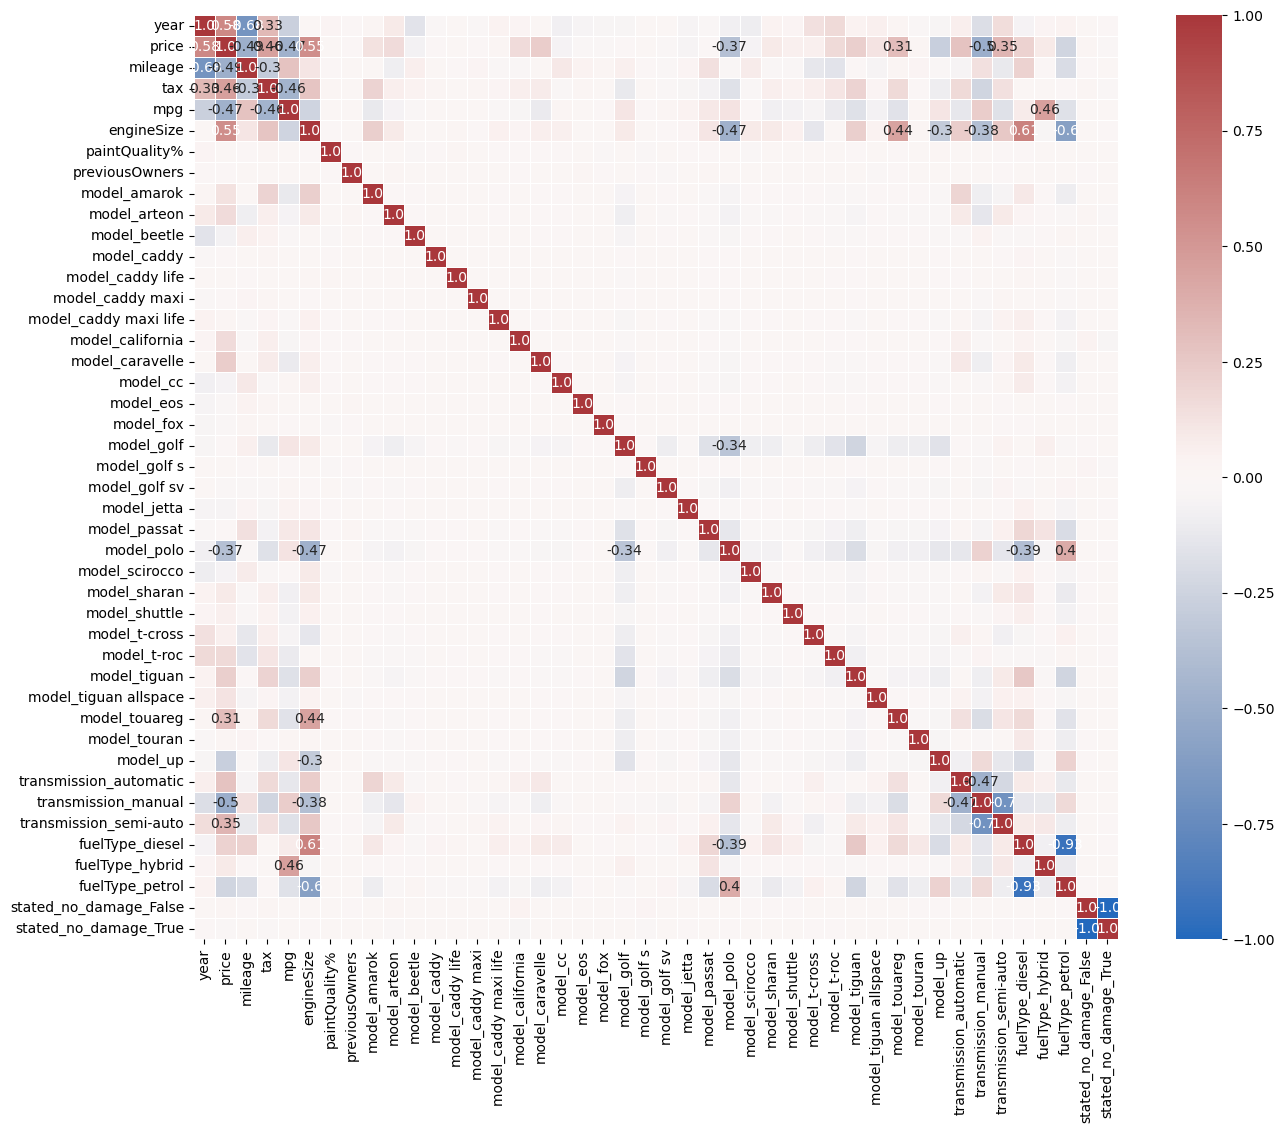

In [ ]:
df_encoded = pd.get_dummies(df_models, columns=['model', "transmission",  "fuelType", "stated_no_damage"])  # Avoid multicollinearity
correlation_matrix = df_encoded.corr().round(2)

fig = plt.figure(figsize=(15, 12))


sns.heatmap(data=correlation_matrix,
            center = 0,
            cmap="vlag",
            annot=np.where(np.absolute(correlation_matrix) >= 0.3, correlation_matrix.values, np.full(correlation_matrix.values.shape, "")), 
            fmt='s',
            square=True,
            linewidths=.5)

plt.show()

#### Part above will be run previously in the function

In [ ]:
def calc_summary_stas(df): 
    
    #df = pd.merge(df, brand_models, on="model")
    #df_summary["tax"] = df["tax"].fillna(df.groupby(["model", "year", "transmission", "fuelType"])["tax"].transform("mean")).round(2)

    df_summary = df[['model', 'year']].drop_duplicates().sort_values(['model', 'year'])

    brand_summary = df.groupby("model")["Brand"].agg(lambda x: x.mode())
    df_summary = pd.merge(brand_summary, df_summary, on="model", how=)
    return df_summary


SyntaxError: expected argument value expression (3319474250.py, line 9)

In [ ]:
df_summary = calc_summary_stas(df)
print(df_summary)

             model     Brand    year
0         1 series       bmw  1970.0
1         1 series       bmw     NaN
2         2 series       bmw  1970.0
3         2 series       bmw     NaN
4              200  mercedes  1970.0
..             ...       ...     ...
314             z4       bmw     NaN
315         zafira      opel  1970.0
316         zafira      opel     NaN
317  zafira tourer      opel  1970.0
318  zafira tourer      opel     NaN

[319 rows x 3 columns]
